# Thông Tin Sinh Viên
- **Họ và tên:** Huỳnh Thế Hy  
- **MSSV:** 051205009083  
## Nội dung
- Môn học: Xử lý ảnh và thị giác máy tính
- Lab1

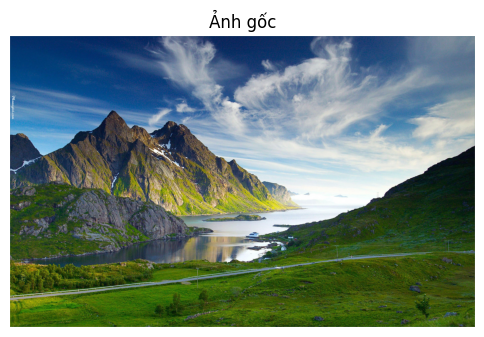

Đã lưu ảnh thành công tại: out.png


In [2]:
import cv2
import matplotlib.pyplot as plt

input_image_path = 'in.jpg'
output_image_path = 'out.png'

# Đọc ảnh gốc bằng OpenCV (mặc định là kênh màu BGR)
original_bgr_image = cv2.imread(input_image_path)

# Chuyển đổi sang hệ màu RGB để thư viện matplotlib hiển thị đúng màu thực tế
original_rgb_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(original_rgb_image)
plt.title("Ảnh gốc")
plt.axis('off') 
plt.show()

cv2.imwrite(output_image_path, original_bgr_image)
print(f"Đã lưu ảnh thành công tại: {output_image_path}")

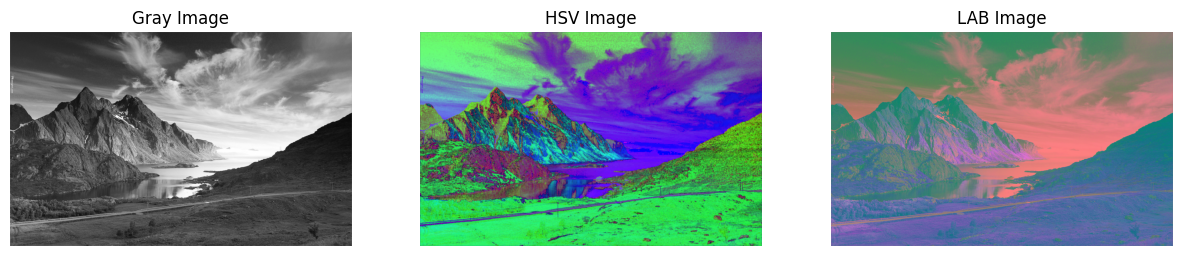

In [3]:
# Chuyển ảnh BGR gốc sang các hệ màu khác nhau
gray_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2GRAY)
hsv_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2HSV)
lab_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Gray Image')
axes[0].axis('off')

axes[1].imshow(hsv_image)
axes[1].set_title('HSV Image')#sắc thái độ bão hoà và giá trị độ sáng
axes[1].axis('off')

axes[2].imshow(lab_image)
axes[2].set_title('LAB Image')# Không gian màu LAB bao gồm ba kênh: L (Lightness - độ sáng), A (Green-Red - màu xanh lá cây đến đỏ), và B (Blue-Yellow - màu xanh dương đến vàng)
axes[2].axis('off')

plt.show()

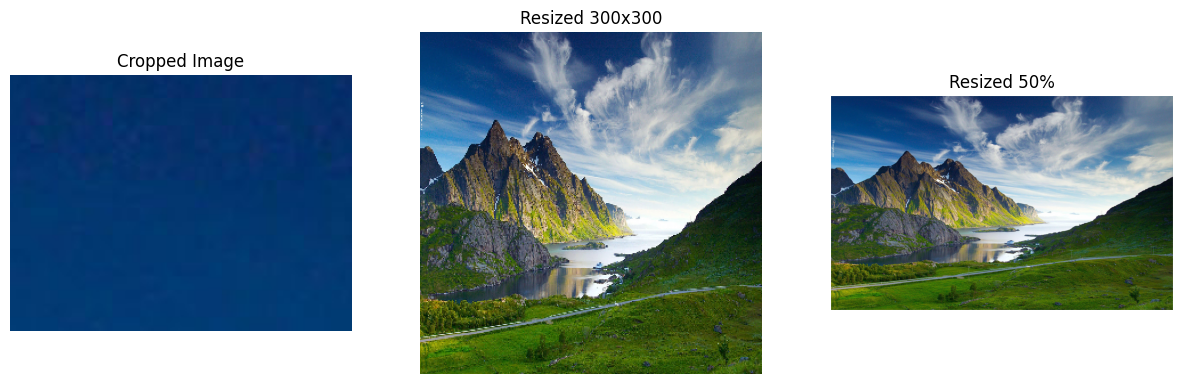

In [4]:
# Xác định tọa độ
y_start, y_end = 50, 200
x_start, x_end = 100, 300
cropped_image = original_rgb_image[y_start:y_end, x_start:x_end] 

# 1. Đưa về một kích thước cố định (chiều rộng, chiều cao)
target_width = 300
target_height = 300
resized_300x300_image = cv2.resize(original_rgb_image, (target_width, target_height))

# 2. Thu nhỏ theo tỷ lệ phần trăm
scale_percent = 0.5 
resized_half_image = cv2.resize(original_rgb_image, None, fx=scale_percent, fy=scale_percent, interpolation=cv2.INTER_LINEAR)
#Biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cropped_image)
axes[0].set_title('Cropped Image')

axes[1].imshow(resized_300x300_image)
axes[1].set_title('Resized 300x300')

axes[2].imshow(resized_half_image)
axes[2].set_title('Resized 50%')

for ax in axes:
    ax.axis('off')
plt.show()

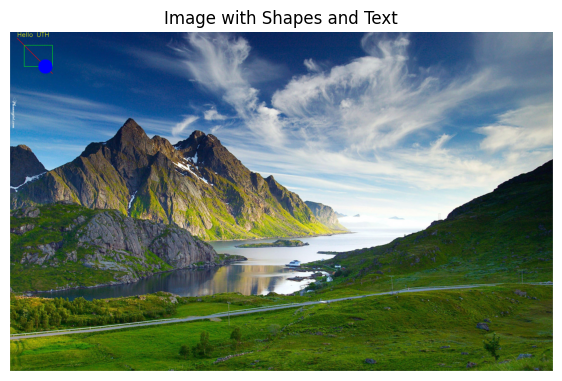

In [5]:
# Tạo một bản sao để vẽ, tránh làm hỏng ảnh gốc
image_for_drawing = original_rgb_image.copy()

# Định nghĩa các mã màu RGB (Red, Green, Blue) để dùng nhiều lần
red_color = (255, 0, 0)
green_color = (0, 255, 0)
blue_color = (0, 0, 255)
yellow_color = (255, 255, 0)

# --- 1. VẼ ĐƯỜNG THẲNG ---
line_start_point = (50, 50)
line_end_point = (300, 300)
line_thickness = 3
cv2.line(image_for_drawing, line_start_point, line_end_point, red_color, line_thickness)

# --- 2. VẼ HÌNH CHỮ NHẬT ---
rect_top_left = (100, 100)
rect_bottom_right = (300, 250)
rect_thickness = 2
cv2.rectangle(image_for_drawing, rect_top_left, rect_bottom_right, green_color, rect_thickness)

# --- 3. VẼ HÌNH TRÒN ---
circle_center = (250, 250)
circle_radius = 50
fill_shape = -1 # Truyền -1 vào độ dày (thickness) để tô kín hình
cv2.circle(image_for_drawing, circle_center, circle_radius, blue_color, fill_shape)

# --- 4. THÊM VĂN BẢN ---
text_content = "Hello UTH"
text_bottom_left = (50, 40)
font_type = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1.5
text_thickness = 2
cv2.putText(image_for_drawing, text_content, text_bottom_left, font_type, font_scale, yellow_color, text_thickness)

# --- PHẦN HIỂN THỊ ---
plt.figure(figsize=(7, 7))
plt.imshow(image_for_drawing)
plt.title("Image with Shapes and Text")
plt.axis('off')
plt.show()